<a href="https://colab.research.google.com/github/DiyaMokal/Hotel-Booking-Cancellation-Prediction/blob/main/Hotel_Booking_Cancellation_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏨 Hotel Booking Cancellation Prediction

## 📌 Problem Statement
Hotel booking cancellations are a major challenge in the hospitality industry, leading to revenue loss and inefficient resource management.

The goal of this project is to build a Machine Learning model that can predict whether a hotel booking will be canceled or not based on customer and booking details.

By accurately predicting cancellations, hotels can:
- Optimize pricing strategies
- Improve customer retention
- Reduce revenue loss
- Enhance operational planning

## 🎯 Objective
To analyze booking data and develop a predictive model that classifies bookings into:
- Canceled
- Not Canceled


## 📚 Importing Required Libraries

In this step, we import all necessary Python libraries for:
- Data manipulation (Pandas, NumPy)
- Data visualization (Matplotlib, Seaborn)
- Machine Learning (Scikit-learn)


## 📥 Loading the Dataset

The dataset contains hotel booking information such as:
- Number of guests
- Stay duration
- Meal type
- Room type
- Booking status (Target Variable)

We load the dataset into a Pandas DataFrame for further analysis.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/booking.csv')
df.head()

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
0,INN00001,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,10/2/2015,Not_Canceled
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,11/6/2018,Not_Canceled
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2/28/2018,Canceled
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,5/20/2017,Canceled
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,4/11/2018,Canceled


## 🔍 Exploratory Data Analysis (EDA)

In this section, we perform initial exploration to understand the dataset:
- Dataset shape (rows and columns)
- Data types of features
- Missing values
- Duplicate entries

This helps in identifying data quality issues before preprocessing.

In [2]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Booking_ID                36285 non-null  object 
 1   number of adults          36285 non-null  int64  
 2   number of children        36285 non-null  int64  
 3   number of weekend nights  36285 non-null  int64  
 4   number of week nights     36285 non-null  int64  
 5   type of meal              36285 non-null  object 
 6   car parking space         36285 non-null  int64  
 7   room type                 36285 non-null  object 
 8   lead time                 36285 non-null  int64  
 9   market segment type       36285 non-null  object 
 10  repeated                  36285 non-null  int64  
 11  P-C                       36285 non-null  int64  
 12  P-not-C                   36285 non-null  int64  
 13  average price             36285 non-null  float64
 14  specia

In [3]:
print("Number of Rows, Columns:", df.shape)

Number of Rows, Columns: (36285, 17)


In [4]:
print("\nColumn Names:\n", df.dtypes)


Column Names:
 Booking_ID                   object
number of adults              int64
number of children            int64
number of weekend nights      int64
number of week nights         int64
type of meal                 object
car parking space             int64
room type                    object
lead time                     int64
market segment type          object
repeated                      int64
P-C                           int64
P-not-C                       int64
average price               float64
special requests              int64
date of reservation          object
booking status               object
dtype: object


In [5]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 Booking_ID                  0
number of adults            0
number of children          0
number of weekend nights    0
number of week nights       0
type of meal                0
car parking space           0
room type                   0
lead time                   0
market segment type         0
repeated                    0
P-C                         0
P-not-C                     0
average price               0
special requests            0
date of reservation         0
booking status              0
dtype: int64


In [6]:
print("\nNumber of Duplicates:", df.duplicated().sum())


Number of Duplicates: 0


## 📊 Statistical Summary

We analyze statistical properties of numerical features such as:
- Mean
- Median
- Standard deviation
- Minimum and maximum values

This helps in understanding the distribution and detecting anomalies.

In [7]:
print(df.describe())

       number of adults  number of children  number of weekend nights  \
count      36285.000000        36285.000000              36285.000000   
mean           1.844839            0.105360                  0.810693   
std            0.518813            0.402704                  0.870590   
min            0.000000            0.000000                  0.000000   
25%            2.000000            0.000000                  0.000000   
50%            2.000000            0.000000                  1.000000   
75%            2.000000            0.000000                  2.000000   
max            4.000000           10.000000                  7.000000   

       number of week nights  car parking space     lead time      repeated  \
count           36285.000000       36285.000000  36285.000000  36285.000000   
mean                2.204602           0.030977     85.239851      0.025630   
std                 1.410946           0.173258     85.938796      0.158032   
min                 0.0000

In [8]:
print("\nStatistical Summary:\n", df.describe(include='all'))


Statistical Summary:
        Booking_ID  number of adults  number of children  \
count       36285      36285.000000        36285.000000   
unique      36285               NaN                 NaN   
top      INN36286               NaN                 NaN   
freq            1               NaN                 NaN   
mean          NaN          1.844839            0.105360   
std           NaN          0.518813            0.402704   
min           NaN          0.000000            0.000000   
25%           NaN          2.000000            0.000000   
50%           NaN          2.000000            0.000000   
75%           NaN          2.000000            0.000000   
max           NaN          4.000000           10.000000   

        number of weekend nights  number of week nights type of meal  \
count               36285.000000           36285.000000        36285   
unique                       NaN                    NaN            4   
top                          NaN                    

## 📈 Data Visualization

Visualizations are used to uncover patterns and relationships in the data.

We use:
- Histograms → Distribution of numerical features
- Countplots → Categorical feature comparison
- Boxplots → Detect outliers
- Scatter plots → Feature relationships
- Heatmap → Correlation analysis

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

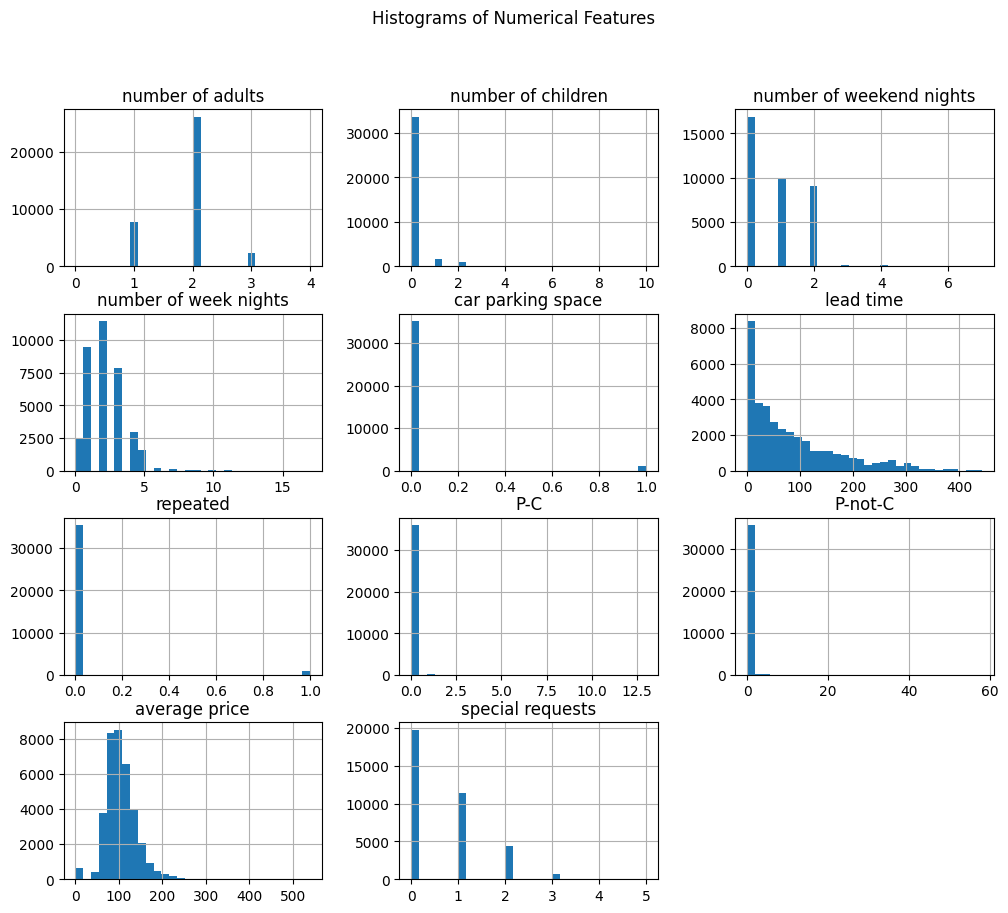

In [10]:
df.hist(figsize=(12, 10), bins=30)
plt.suptitle("Histograms of Numerical Features")
plt.show()

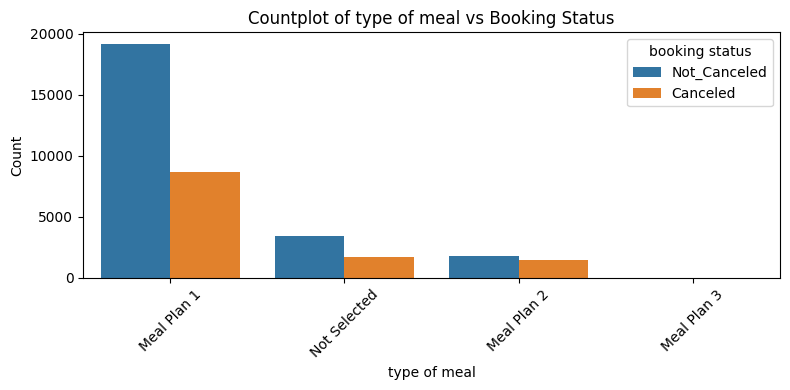

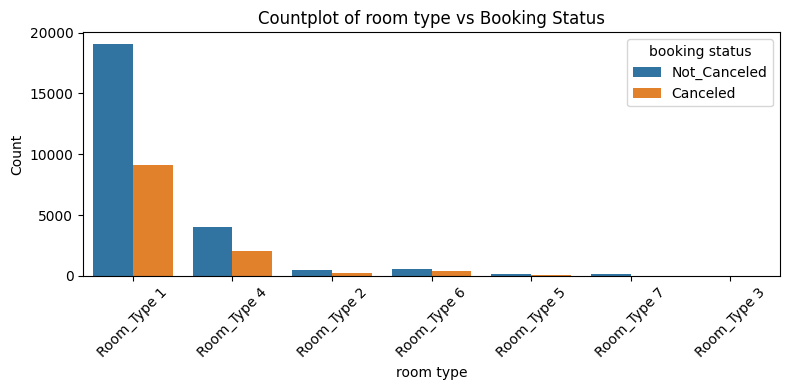

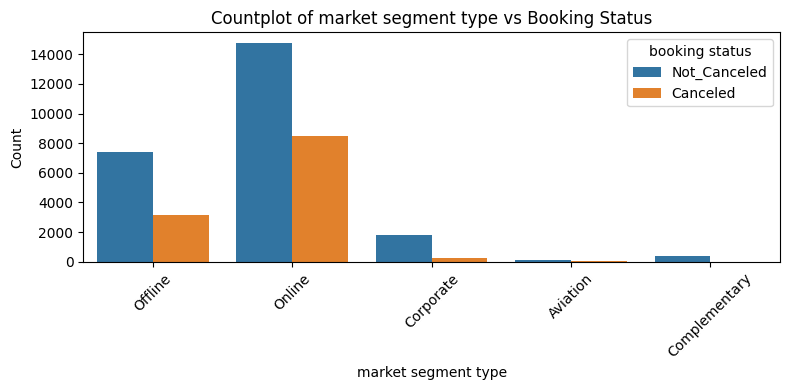

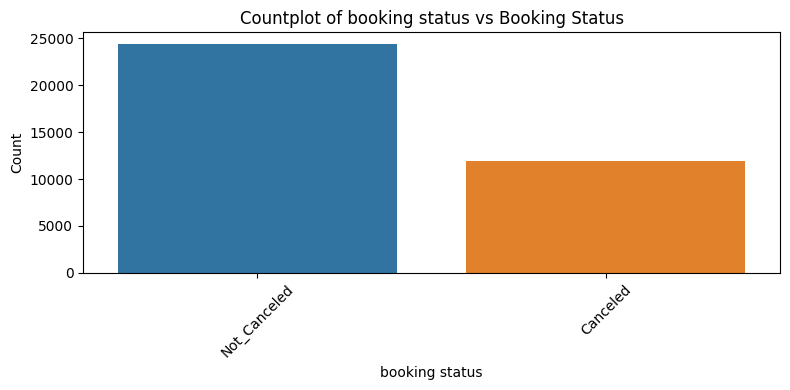

In [11]:
categorical_cols = ['type of meal', 'room type', 'market segment type', 'booking status']

for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, hue='booking status')
    plt.title(f"Countplot of {col} vs Booking Status")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

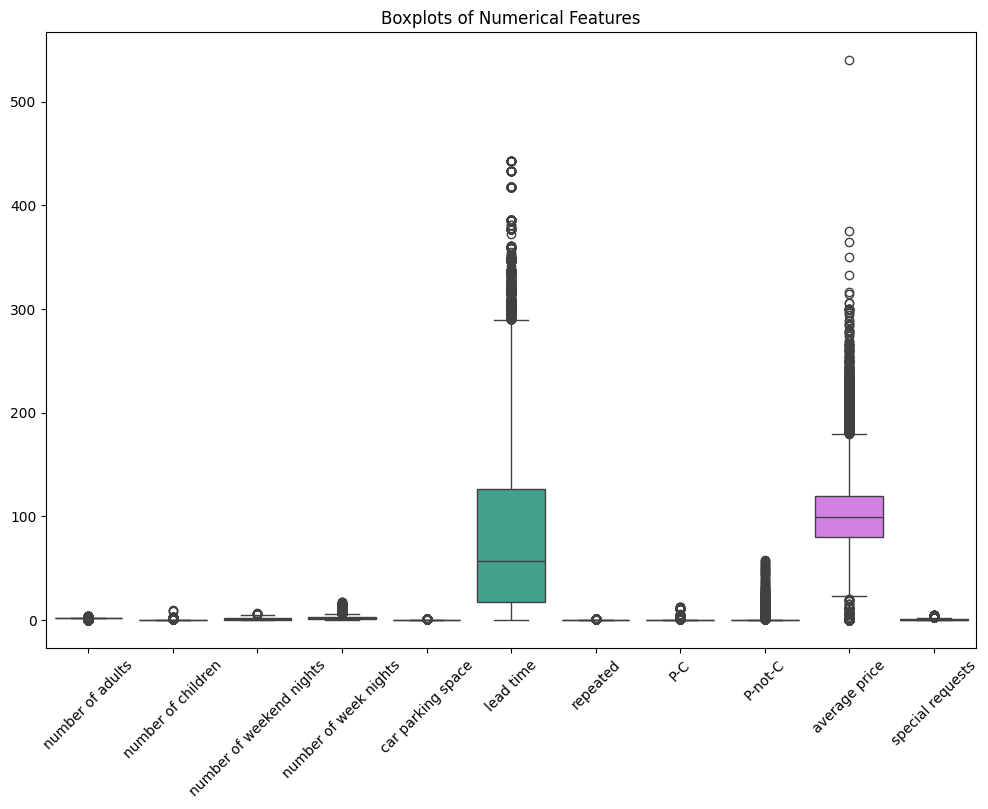

In [12]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=df.select_dtypes(include=['int64','float64']))
plt.title("Boxplots of Numerical Features")
plt.xticks(rotation=45)
plt.show()

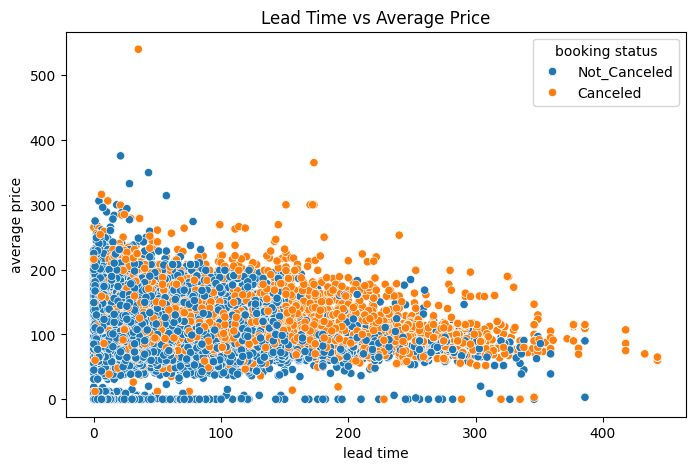

In [13]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="lead time", y="average price", hue="booking status")
plt.title("Lead Time vs Average Price")
plt.show()

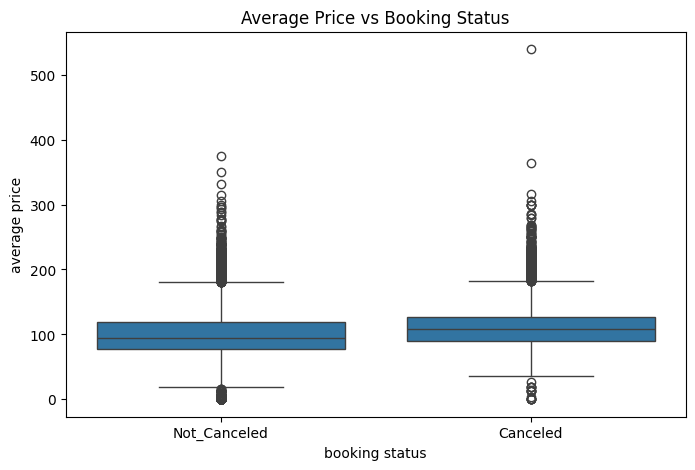

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="booking status", y="average price")
plt.title("Average Price vs Booking Status")
plt.show()

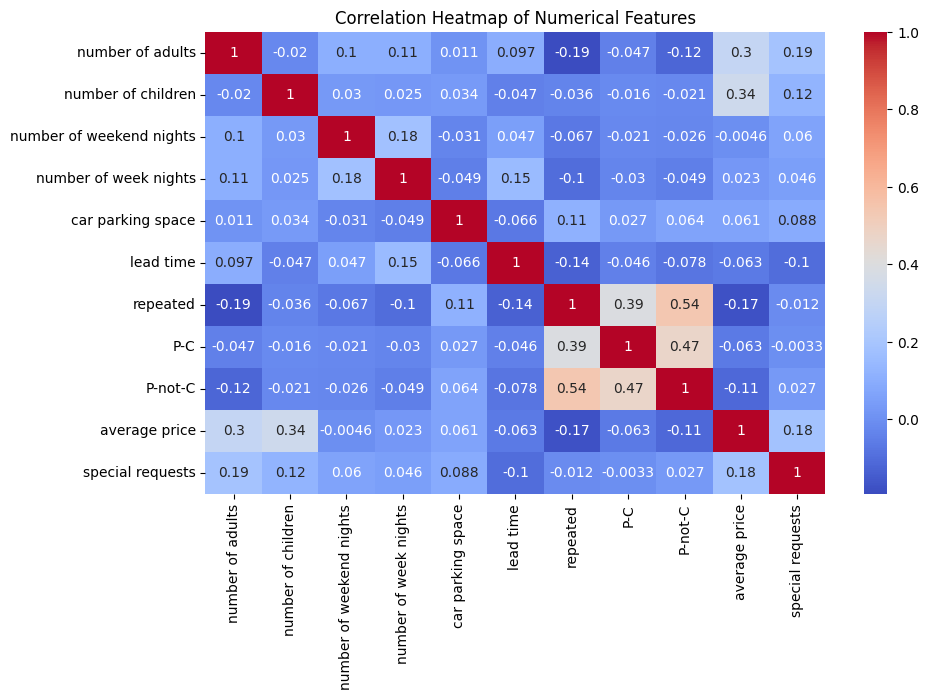

In [15]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

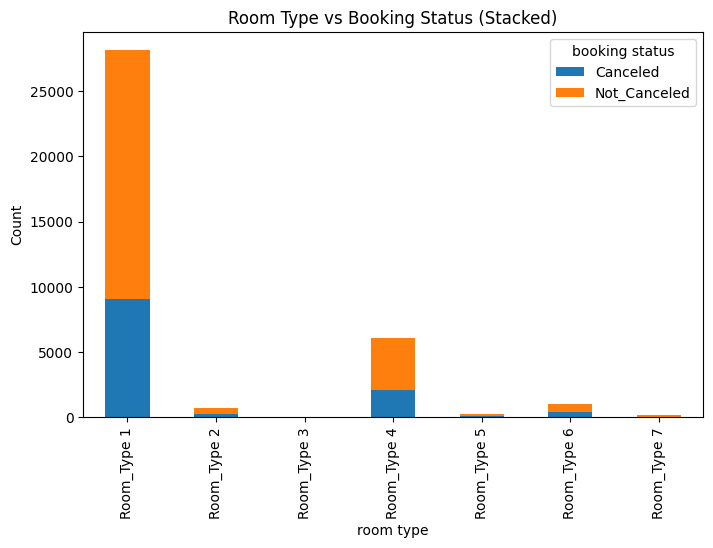

In [16]:
cross_tab = pd.crosstab(df['room type'], df['booking status'])
cross_tab.plot(kind='bar', stacked=True, figsize=(8, 5))
plt.title("Room Type vs Booking Status (Stacked)")
plt.ylabel("Count")
plt.show()

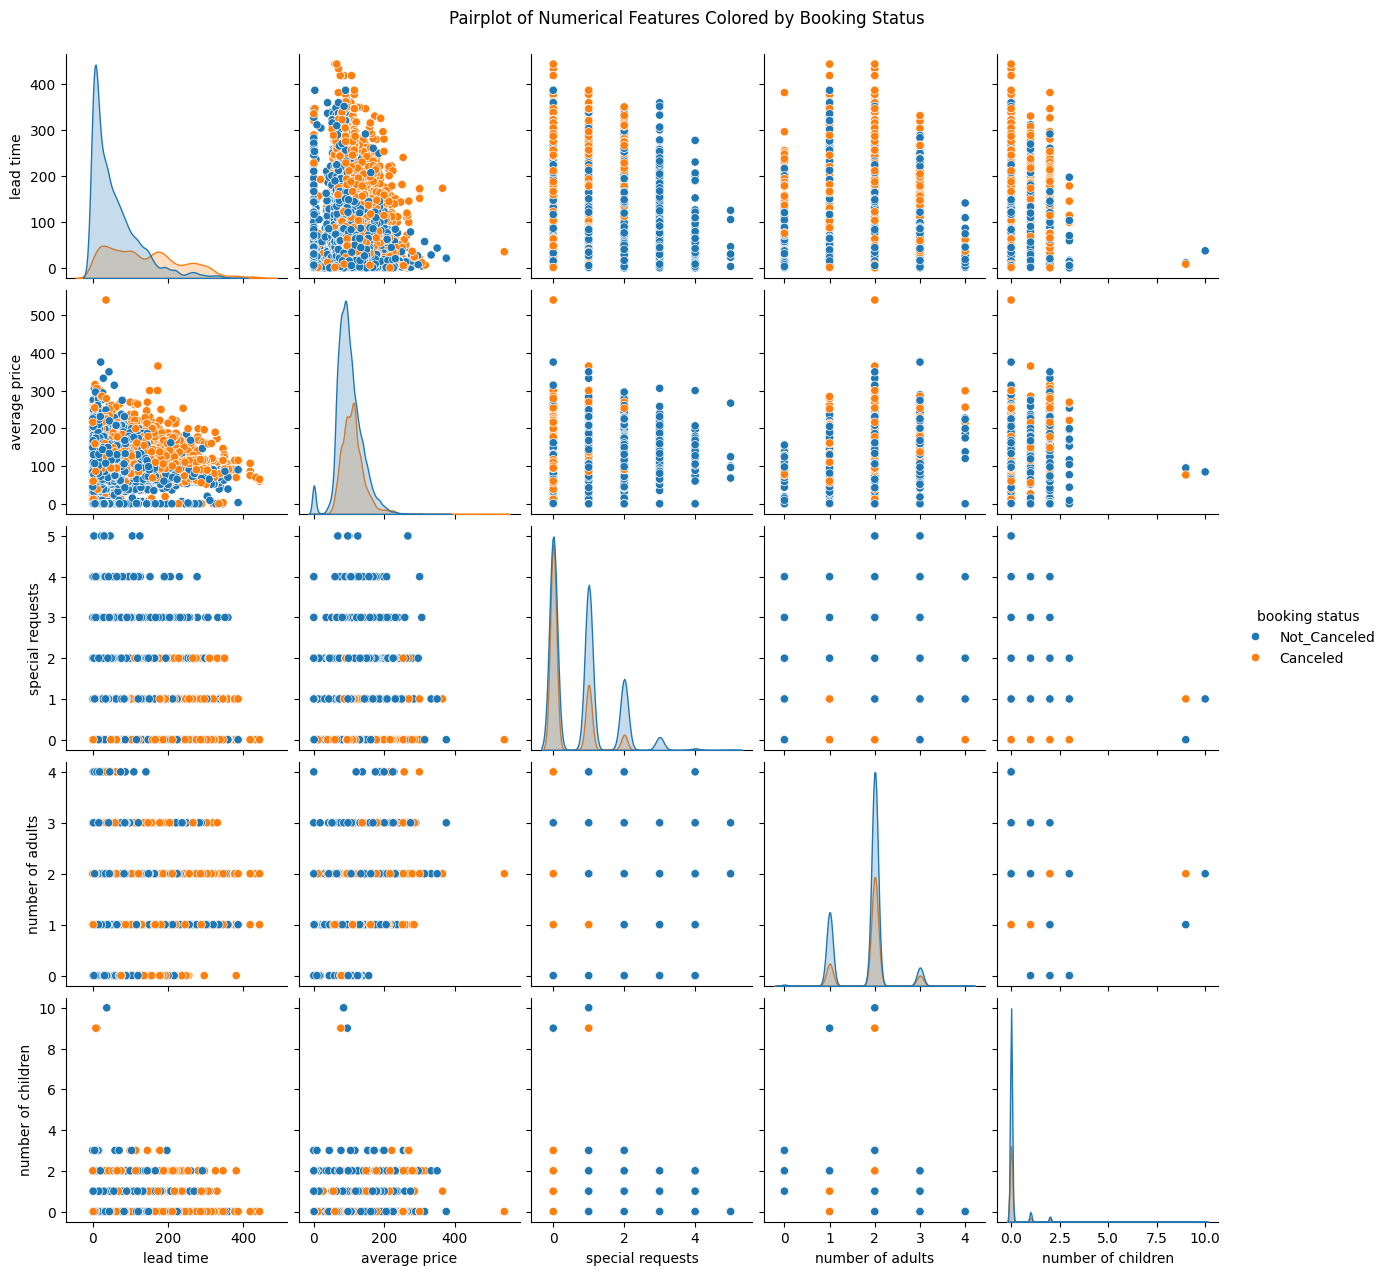

In [17]:
num_features = ['lead time', 'average price', 'special requests','number of adults', 'number of children']

# Create pairplot with target hue
sns.pairplot(df[num_features + ['booking status']], hue='booking status', diag_kind='kde')
plt.suptitle("Pairplot of Numerical Features Colored by Booking Status", y=1.02)
plt.show()

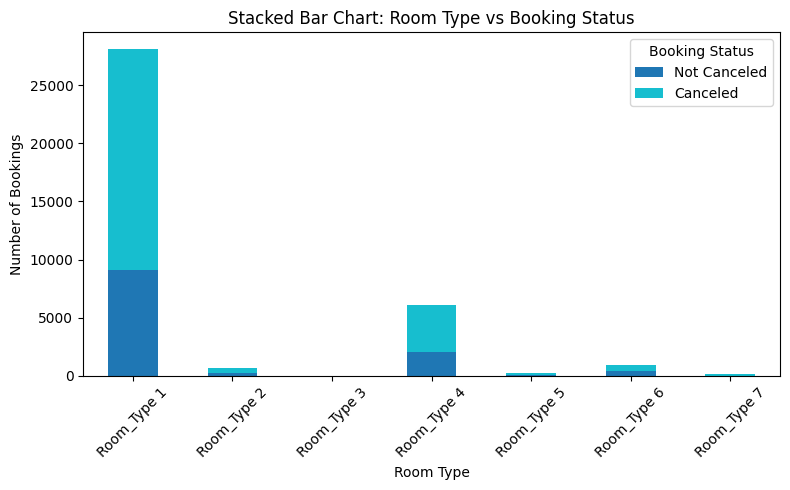

In [18]:
cross_tab = pd.crosstab(df['room type'], df['booking status'])

# Plot stacked bar chart
cross_tab.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='tab10')
plt.title("Stacked Bar Chart: Room Type vs Booking Status")
plt.xlabel("Room Type")
plt.ylabel("Number of Bookings")
plt.legend(title="Booking Status", labels=["Not Canceled", "Canceled"])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Correlation Matrix (Pearson’s r):
                          number of adults  number of children  \
number of adults                  1.000000           -0.020027   
number of children               -0.020027            1.000000   
number of weekend nights          0.103316            0.029536   
number of week nights             0.105416            0.024680   
car parking space                 0.011467            0.034198   
lead time                         0.097014           -0.047058   
repeated                         -0.192175           -0.036371   
P-C                              -0.047395           -0.016398   
P-not-C                          -0.119106           -0.021201   
average price                     0.296832            0.337491   
special requests                  0.189317            0.124363   

                          number of weekend nights  number of week nights  \
number of adults                          0.103316               0.105416   
number of children 

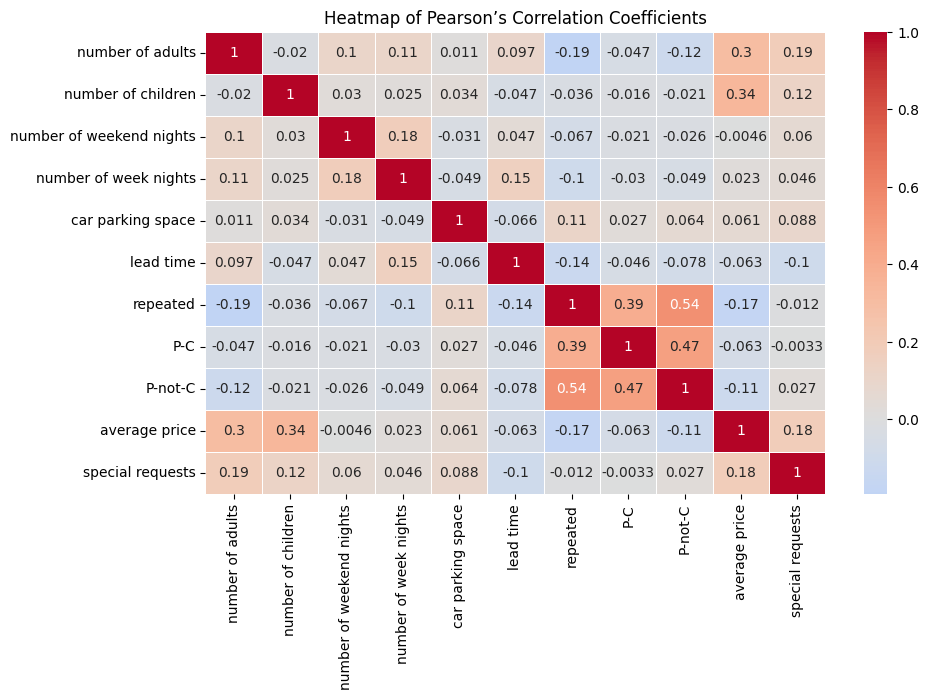

In [19]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix using Pearson's r
corr_matrix = numeric_df.corr(method='pearson')

# Display correlation values
print("Correlation Matrix (Pearson’s r):")
print(corr_matrix)

# Visualize correlation matrix as a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Heatmap of Pearson’s Correlation Coefficients")
plt.show()

4th Practical

In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

df = pd.read_csv("/content/booking.csv")
print("Shape:", df.shape)
print(df.head())

Shape: (36285, 17)
  Booking_ID  number of adults  number of children  number of weekend nights  \
0   INN00001                 1                   1                         2   
1   INN00002                 1                   0                         1   
2   INN00003                 2                   1                         1   
3   INN00004                 1                   0                         0   
4   INN00005                 1                   0                         1   

   number of week nights  type of meal  car parking space    room type  \
0                      5   Meal Plan 1                  0  Room_Type 1   
1                      3  Not Selected                  0  Room_Type 1   
2                      3   Meal Plan 1                  0  Room_Type 1   
3                      2   Meal Plan 1                  0  Room_Type 1   
4                      2  Not Selected                  0  Room_Type 1   

   lead time market segment type  repeated  P-C  P-not-

In [21]:
print("\nMissing values before handling:\n", df.isnull().sum())


Missing values before handling:
 Booking_ID                  0
number of adults            0
number of children          0
number of weekend nights    0
number of week nights       0
type of meal                0
car parking space           0
room type                   0
lead time                   0
market segment type         0
repeated                    0
P-C                         0
P-not-C                     0
average price               0
special requests            0
date of reservation         0
booking status              0
dtype: int64


In [22]:
df['number of children'] = df['number of children'].fillna(df['number of children'].median())
df['type of meal'] = df['type of meal'].fillna("Unknown")
df['room type'] = df['room type'].fillna("Unknown")
print("\nMissing values after handling:\n", df.isnull().sum())


Missing values after handling:
 Booking_ID                  0
number of adults            0
number of children          0
number of weekend nights    0
number of week nights       0
type of meal                0
car parking space           0
room type                   0
lead time                   0
market segment type         0
repeated                    0
P-C                         0
P-not-C                     0
average price               0
special requests            0
date of reservation         0
booking status              0
dtype: int64


In [23]:
print("\nDuplicates before:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicates after:", df.duplicated().sum())


Duplicates before: 0
Duplicates after: 0


In [24]:
for col in ['lead time', 'average price']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

print("\nShape after outlier removal:", df.shape)


Shape after outlier removal: (33345, 17)


In [25]:
label_cols = ['booking status']  # target
df['booking status'] = LabelEncoder().fit_transform(df['booking status'])

In [26]:
categorical_cols = ['type of meal', 'room type', 'market segment type']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [27]:
scaler = StandardScaler()
num_cols = ['number of adults', 'number of children', 'number of weekend nights','number of week nights', 'lead time', 'average price', 'special requests']
df[num_cols] = scaler.fit_transform(df[num_cols])

In [28]:
df['date of reservation'] = pd.to_datetime(df['date of reservation'], errors='coerce')

In [29]:
df['Res_Year'] = df['date of reservation'].dt.year
df['Res_Month'] = df['date of reservation'].dt.month
df['Price_per_Adult'] = df['average price'] / (df['number of adults'] + 1)

In [30]:
X = df.drop(['Booking_ID', 'date of reservation', 'booking status'], axis=1)
y = df ['booking status']

X_train, X_test, y_train, y_test =train_test_split(
    X, y, test_size=0.2, random_state=42
    )

print("\nTraining Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)


Training Set Shape: (26676, 26)
Testing Set Shape: (6669, 26)


In [31]:
print("\n✅ Dataset cleaned (missing values, duplicates, outliers handled).")
print("✅ Data transformed (scaled, encoded).")
print("✅ Features engineered (date & interaction features).")
print("✅ Dataset split into train/test sets ready for ML.")


✅ Dataset cleaned (missing values, duplicates, outliers handled).
✅ Data transformed (scaled, encoded).
✅ Features engineered (date & interaction features).
✅ Dataset split into train/test sets ready for ML.


5th Practical

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, classification_report
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# For reproducibility
RND = 42
cv = 5

In [33]:
# Step 2: Load Cleaned Dataset (result from Experiment 4)
df = pd.read_csv("/content/booking.csv")

# Step 3: Data Preprocessing
df = df.drop(columns=["Booking_ID", "date of reservation"], errors='ignore')

# Encode target variable (booking status)
le = LabelEncoder()
df["booking status"] = le.fit_transform(df["booking status"])

# One-hot encode categorical features
df = pd.get_dummies(df, drop_first=True)

# Handle missing values
df = df.fillna(df.mean())

In [34]:
# Step 3: Data Preprocessing
df = df.drop(columns=["Booking_ID", "date of reservation"], errors='ignore')

# Encode target variable (booking status)
le = LabelEncoder()
df["booking status"] = le.fit_transform(df["booking status"])

# One-hot encode categorical features
df = pd.get_dummies(df, drop_first=True)

# Handle missing values
df = df.fillna(df.mean())

In [35]:
# Step 4: Define Features (X) and Target (y)
X = df.drop("booking status", axis=1)
y = df["booking status"]

In [36]:
# Step 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
# Step 6: Standardize Features (important for SVM, KNN, Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
# Step 7: Define Candidate Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine": SVC(kernel='rbf', probability=True, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

In [39]:
# Step 8: Train, Cross-Validate, and Evaluate Each Model
results = []

for name, model in models.items():
    # Select scaled or unscaled data based on model type
    if name in ["Logistic Regression", "K-Nearest Neighbors", "Support Vector Machine"]:
        Xtr, Xts = X_train_scaled, X_test_scaled
    else:
        Xtr, Xts = X_train, X_test

In [40]:
# Cross-validation
cv_score = cross_val_score(model, Xtr, y_train, cv=5, scoring='accuracy').mean()

In [41]:
 # Train and Predict
model.fit(Xtr, y_train)
y_pred = model.predict(Xts)

In [42]:
 # Evaluation Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

results.append([name, acc, prec, rec, f1, cv_score])

In [43]:
# Step 9: Create Observation Table
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score", "CV Accuracy"])
results_df = results_df.sort_values(by="Accuracy", ascending=False)
print("\n📋 Model Comparison Table:\n")
print(results_df.round(3))


📋 Model Comparison Table:

               Model  Accuracy  Precision  Recall  F1-Score  CV Accuracy
0  Gradient Boosting     0.846      0.854   0.927     0.889        0.849


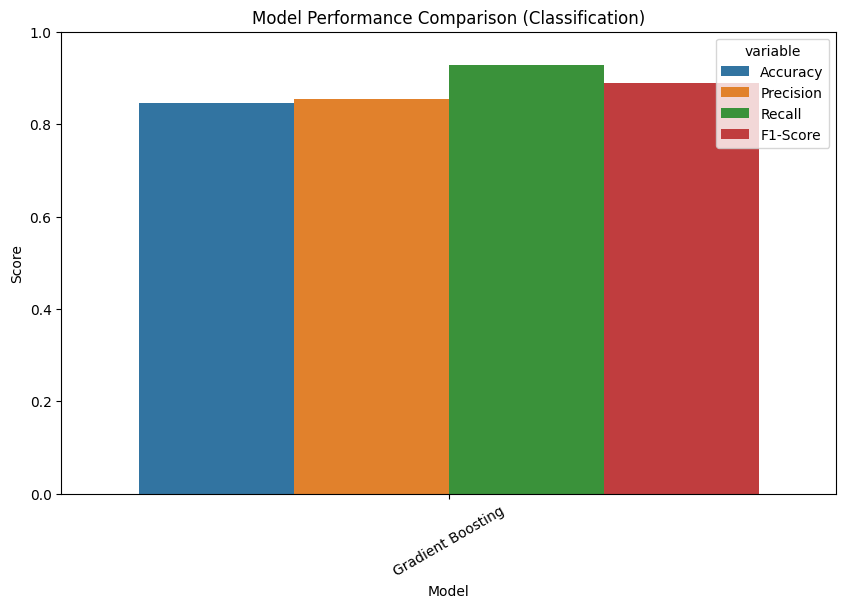

In [44]:
# Step 10: Visualization – Bar Chart of Metrics
plt.figure(figsize=(10,6))
sns.barplot(data=results_df.melt(id_vars="Model", value_vars=["Accuracy","Precision","Recall","F1-Score"]),
            x="Model", y="value", hue="variable")
plt.title("Model Performance Comparison (Classification)")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=30)
plt.show()


🏆 Best Model Selected: Gradient Boosting



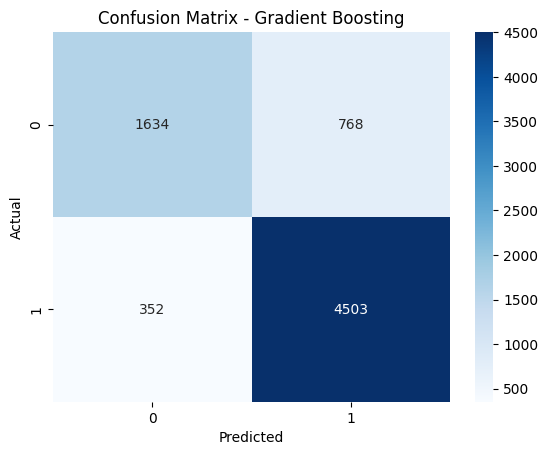

In [45]:
# Step 11: Confusion Matrix for Best Model
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
print(f"\n🏆 Best Model Selected: {best_model_name}\n")
if best_model_name in ["Logistic Regression", "K-Nearest Neighbors", "Support Vector Machine"]:
    best_model.fit(X_train_scaled, y_train)
    y_pred_best = best_model.predict(X_test_scaled)
else:
    best_model.fit(X_train, y_train)
    y_pred_best = best_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [46]:
# Step 12: Final Summary
print(f"\n🔍 Classification Report ({best_model_name}):\n")
print(classification_report(y_test, y_pred_best))


🔍 Classification Report (Gradient Boosting):

              precision    recall  f1-score   support

           0       0.82      0.68      0.74      2402
           1       0.85      0.93      0.89      4855

    accuracy                           0.85      7257
   macro avg       0.84      0.80      0.82      7257
weighted avg       0.84      0.85      0.84      7257



6th Practical

In [47]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
df = pd.read_csv('/content/booking.csv')
print(df.head())

  Booking_ID  number of adults  number of children  number of weekend nights  \
0   INN00001                 1                   1                         2   
1   INN00002                 1                   0                         1   
2   INN00003                 2                   1                         1   
3   INN00004                 1                   0                         0   
4   INN00005                 1                   0                         1   

   number of week nights  type of meal  car parking space    room type  \
0                      5   Meal Plan 1                  0  Room_Type 1   
1                      3  Not Selected                  0  Room_Type 1   
2                      3   Meal Plan 1                  0  Room_Type 1   
3                      2   Meal Plan 1                  0  Room_Type 1   
4                      2  Not Selected                  0  Room_Type 1   

   lead time market segment type  repeated  P-C  P-not-C  average price  \

In [49]:
df = df.drop(columns=["Booking_ID", "date of reservation"], errors='ignore')

In [50]:
label_encoder = LabelEncoder()
df["booking status"] = label_encoder.fit_transform(df["booking status"])

In [51]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded = df_encoded.fillna(df_encoded.mean())

In [52]:
X = df_encoded.drop("booking status", axis=1)
y = df_encoded["booking status"]

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [54]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [55]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [56]:
y_pred = knn.predict(X_test_scaled)

In [57]:
print("\n✅ Model Evaluation Results:")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


✅ Model Evaluation Results:
Accuracy: 0.852

Confusion Matrix:
 [[1757  645]
 [ 428 4427]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.73      0.77      2402
           1       0.87      0.91      0.89      4855

    accuracy                           0.85      7257
   macro avg       0.84      0.82      0.83      7257
weighted avg       0.85      0.85      0.85      7257



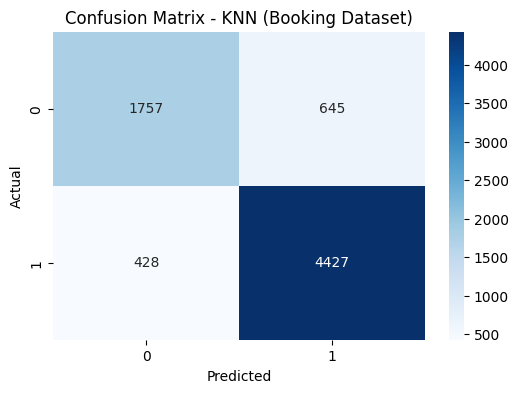

In [58]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - KNN (Booking Dataset)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

7th Practical

In [59]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
X = df_encoded.drop("booking status", axis=1)
y = df_encoded["booking status"]

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [62]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [63]:
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

GaussianNB()

In [64]:
y_pred = nb.predict(X_test_scaled)

In [65]:
y_prob = nb.predict_proba(X_test_scaled)[:, 1]

In [66]:
print("\n✅ Model Evaluation Results:")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


✅ Model Evaluation Results:
Accuracy: 0.41

Confusion Matrix:
 [[2315   87]
 [4195  660]]

Classification Report:
               precision    recall  f1-score   support

           0       0.36      0.96      0.52      2402
           1       0.88      0.14      0.24      4855

    accuracy                           0.41      7257
   macro avg       0.62      0.55      0.38      7257
weighted avg       0.71      0.41      0.33      7257



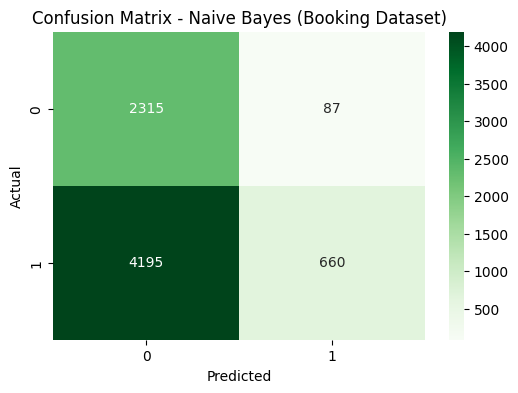

In [67]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Naive Bayes (Booking Dataset)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

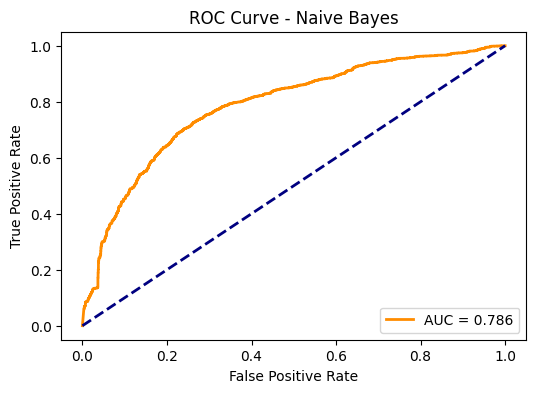

ROC-AUC Score: 0.786


In [68]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='AUC = %0.3f' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('ROC Curve - Naive Bayes')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

print(f"ROC-AUC Score: {roc_auc:.3f}")

In [69]:
cv_scores = cross_val_score(nb, X_train_scaled, y_train, cv=5, scoring='accuracy')
print("\nCross-Validation Accuracy Scores:", np.round(cv_scores, 3))
print("Mean CV Accuracy:", round(cv_scores.mean(), 3))


Cross-Validation Accuracy Scores: [0.411 0.409 0.377 0.381 0.407]
Mean CV Accuracy: 0.397


In [70]:
nb_raw = GaussianNB()
nb_raw.fit(X_train, y_train)
y_pred_raw = nb_raw.predict(X_test)
raw_acc = accuracy_score(y_test, y_pred_raw)

print("\nAccuracy with Scaled Features:", round(accuracy_score(y_test, y_pred), 3))
print("Accuracy with Raw Features:", round(raw_acc, 3))


Accuracy with Scaled Features: 0.41
Accuracy with Raw Features: 0.411


In [71]:
summary = pd.DataFrame({
    "Model Version": ["Naive Bayes (Scaled)", "Naive Bayes (Raw)"],
    "Accuracy": [accuracy_score(y_test, y_pred), raw_acc],
    "ROC-AUC": [roc_auc, np.nan],
    "Mean CV Accuracy": [cv_scores.mean(), np.nan]
})

print("\n📊 Summary of Results:")
print(summary.round(3))


📊 Summary of Results:
          Model Version  Accuracy  ROC-AUC  Mean CV Accuracy
0  Naive Bayes (Scaled)     0.410    0.786             0.397
1     Naive Bayes (Raw)     0.411      NaN               NaN


## 🤖 Model Building

We train multiple machine learning models to predict booking cancellations:

- Logistic Regression
- Support Vector Machine (SVM)
- (You can add more like Random Forest, etc.)

Each model learns patterns from the training data.

In [155]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

In [156]:
df = df.drop(columns=["Booking_ID", "date of reservation"], errors='ignore')

# Encode target variable
label_encoder = LabelEncoder()
df["booking status"] = label_encoder.fit_transform(df["booking status"])

# One-hot encode categorical features
df = pd.get_dummies(df, drop_first=True)

# Handle missing values
df = df.fillna(df.mean())

In [74]:
# Step 4: Split Features & Target
X = df.drop("booking status", axis=1)
y = df["booking status"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [75]:
# Step 5: Initialize Models
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [76]:
# Step 6: Train Models
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [77]:
# Step 7: Predictions
y_pred_dt = dt_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

In [78]:
# Step 8: Evaluation Function
def evaluate_model(name, y_test, y_pred, model):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    print(f"\n📊 {name} Performance:")
    print(f"Accuracy: {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall: {rec:.3f}")
    print(f"F1-Score: {f1:.3f}")
    print(f"ROC-AUC: {auc:.3f}")
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    return [name, acc, prec, rec, f1, auc]

## 📊 Model Evaluation

We evaluate model performance using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Score
- Confusion Matrix

This helps in selecting the best performing model.

In [79]:
# Step 9: Evaluate Both Models
results = []
results.append(evaluate_model("Decision Tree", y_test, y_pred_dt, dt_model))
results.append(evaluate_model("Random Forest", y_test, y_pred_rf, rf_model))


📊 Decision Tree Performance:
Accuracy: 0.856
Precision: 0.898
Recall: 0.885
F1-Score: 0.892
ROC-AUC: 0.845

Confusion Matrix:
 [[1913  489]
 [ 557 4298]]

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.80      0.79      2402
           1       0.90      0.89      0.89      4855

    accuracy                           0.86      7257
   macro avg       0.84      0.84      0.84      7257
weighted avg       0.86      0.86      0.86      7257


📊 Random Forest Performance:
Accuracy: 0.888
Precision: 0.900
Recall: 0.937
F1-Score: 0.918
ROC-AUC: 0.945

Confusion Matrix:
 [[1899  503]
 [ 308 4547]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.79      0.82      2402
           1       0.90      0.94      0.92      4855

    accuracy                           0.89      7257
   macro avg       0.88      0.86      0.87      7257
weighted avg       0.89      0.89      0.

In [80]:
# Step 10: Cross-Validation for Stability
for name, model in [("Decision Tree", dt_model), ("Random Forest", rf_model)]:
    cv_scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")
    print(f"\n{name} CV Mean Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")


Decision Tree CV Mean Accuracy: 0.856 ± 0.006

Random Forest CV Mean Accuracy: 0.884 ± 0.003


In [81]:
# Step 11: Comparison Table
results_df = pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","F1-Score","ROC-AUC"])
print("\n📋 Model Comparison Summary:")
print(results_df.round(3))


📋 Model Comparison Summary:
           Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0  Decision Tree     0.856      0.898   0.885     0.892    0.845
1  Random Forest     0.888      0.900   0.937     0.918    0.945


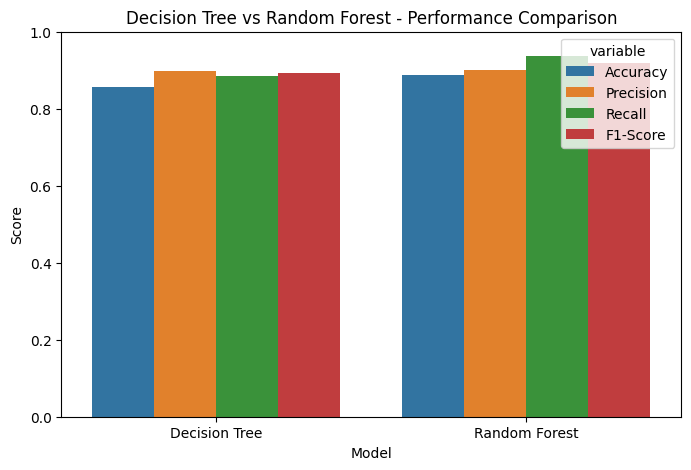

In [82]:
# Step 12: Visualization of Comparison
plt.figure(figsize=(8,5))
sns.barplot(data=results_df.melt(id_vars="Model", value_vars=["Accuracy","Precision","Recall","F1-Score"]),x="Model", y="value", hue="variable")
plt.title("Decision Tree vs Random Forest - Performance Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.show()

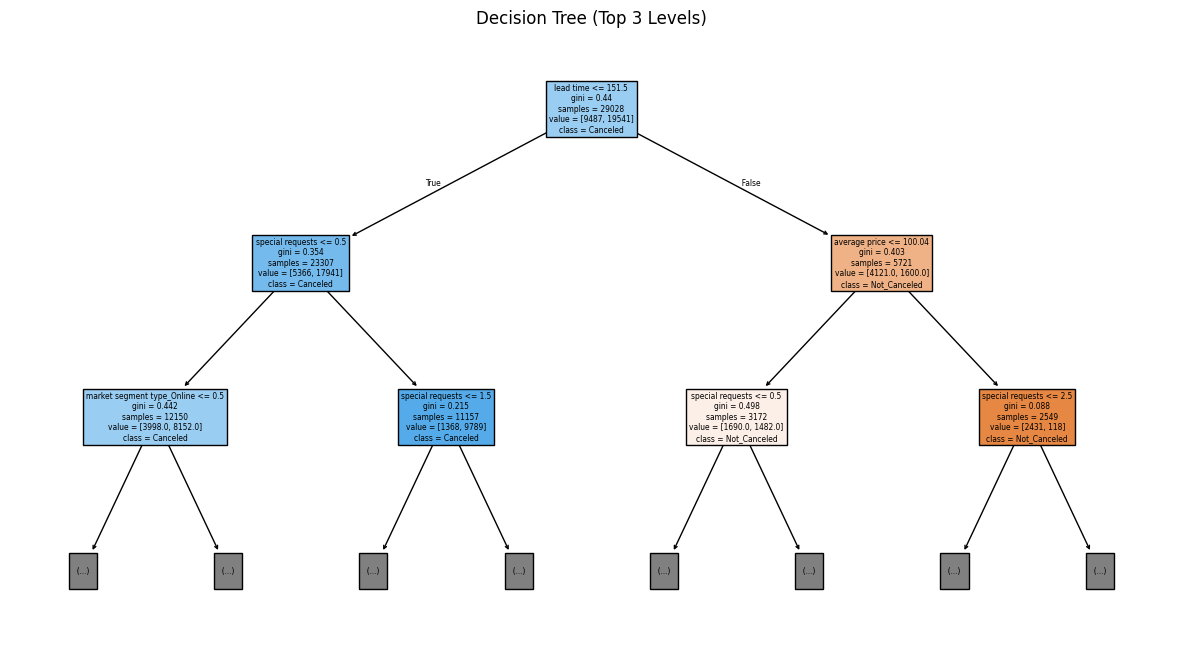

In [83]:
# Step 13: Visualize Decision Tree
plt.figure(figsize=(15,8))
plot_tree(dt_model, filled=True, feature_names=X.columns, class_names=["Not_Canceled","Canceled"], max_depth=2)
plt.title("Decision Tree (Top 3 Levels)")
plt.show()

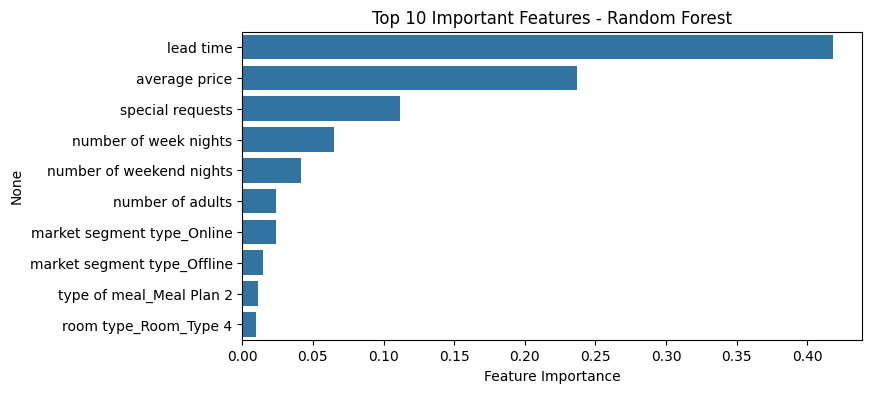

In [84]:
# Step 14: Feature Importance (Random Forest)
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)[:10]
plt.figure(figsize=(8,4))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Top 10 Important Features - Random Forest")
plt.xlabel("Feature Importance")
plt.show()

In [85]:
# Step 15: Summary & Best Model Decision
best_model = results_df.iloc[results_df['Accuracy'].idxmax()]
print(f"\n🏆 Best Model: {best_model['Model']} with Accuracy = {best_model['Accuracy']:.3f}")


🏆 Best Model: Random Forest with Accuracy = 0.888


## 🌳 Bagging Classifier with Decision Tree

In this step, we implement a Bagging Classifier using Decision Tree as the base estimator. Multiple decision trees are trained on different subsets of the data, and their predictions are combined to improve accuracy and reduce overfitting.

In [146]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

In [147]:
# Drop unnecessary columns
df = df.drop(columns=["Booking_ID", "date of reservation"], errors='ignore')

# Encode categorical target
le = LabelEncoder()
df["booking status"] = le.fit_transform(df["booking status"])

# One-hot encode other categorical columns
df = pd.get_dummies(df, drop_first=True)

In [148]:
# Step 3: Define X and y
X = df.drop("booking status", axis=1)
y = df["booking status"]

In [149]:
# Step 4: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [150]:
# Step 5: Train a Decision Tree Classifier (base model)
base_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
base_tree.fit(X_train, y_train)

y_pred_tree = base_tree.predict(X_test)

print("\n🌳 Decision Tree Performance:")
print("Accuracy:", round(accuracy_score(y_test, y_pred_tree), 3))
print("\nClassification Report:\n", classification_report(y_test, y_pred_tree))


🌳 Decision Tree Performance:
Accuracy: 0.832

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.70      0.73      2402
           1       0.86      0.90      0.88      4855

    accuracy                           0.83      7257
   macro avg       0.81      0.80      0.81      7257
weighted avg       0.83      0.83      0.83      7257



In [151]:
# Step 6: Implement Bagging Classifier with Decision Tree as base estimator
bag_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=5, random_state=42),  # ✅ use 'estimator' instead of 'base_estimator'
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

bag_model.fit(X_train, y_train)
y_pred_bag = bag_model.predict(X_test)

print("\n🧩 Bagging Classifier Performance:")
print("Accuracy:", round(accuracy_score(y_test, y_pred_bag), 3))
print("\nClassification Report:\n", classification_report(y_test, y_pred_bag))


🧩 Bagging Classifier Performance:
Accuracy: 0.835

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.68      0.73      2402
           1       0.85      0.91      0.88      4855

    accuracy                           0.83      7257
   macro avg       0.82      0.80      0.81      7257
weighted avg       0.83      0.83      0.83      7257



In [93]:
# Step 7: Compare Model Performance
results = pd.DataFrame({
    "Model": ["Decision Tree", "Bagging (with Decision Trees)"],
    "Accuracy": [
        round(accuracy_score(y_test, y_pred_tree), 3),
        round(accuracy_score(y_test, y_pred_bag), 3)
    ]
})

print("\n📊 Observation Table:")
print(results)


📊 Observation Table:
                           Model  Accuracy
0                  Decision Tree     0.832
1  Bagging (with Decision Trees)     0.835


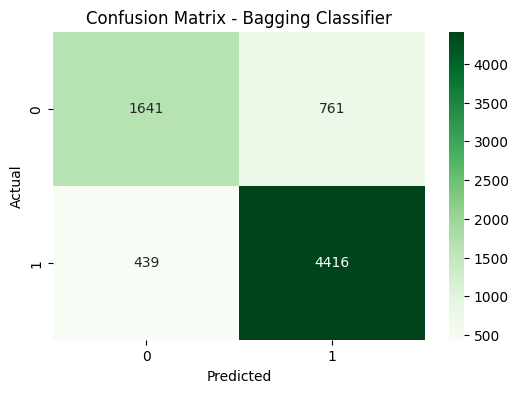

In [94]:
# Step 8: Visualize Confusion Matrix for Bagging Classifier
cm = confusion_matrix(y_test, y_pred_bag)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Bagging Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## ⚡ AdaBoost & 📈 Gradient Boosting

- **AdaBoost:** Combines weak models by giving more weight to misclassified data points so that future models focus on correcting those errors.

- **Gradient Boosting:** Builds models sequentially where each new model reduces the overall prediction error using gradient descent.

### 📌 Why used:
Both methods improve model accuracy and create stronger predictions by combining multiple weak learners.

In [133]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

In [152]:
# Encode target column
le = LabelEncoder()
df["booking status"] = le.fit_transform(df["booking status"])

# One-hot encode other categorical columns
df = pd.get_dummies(df, drop_first=True)

In [153]:
#Step 3: Define features and target
X = df.drop("booking status", axis=1)
y = df["booking status"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [154]:
# Step 4: Initialize and train AdaBoost classifier
ada_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),  # weak learner
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

ada_clf.fit(X_train, y_train)
y_pred_ada = ada_clf.predict(X_test)

In [144]:
# Step 5: Initialize and train Gradient Boosting classifier
gb_clf = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_clf.fit(X_train, y_train)
y_pred_gb = gb_clf.predict(X_test)

In [145]:
# Step 6: Evaluate both models
print("\n⚡ AdaBoost Classifier Performance:")
print("Accuracy:", round(accuracy_score(y_test, y_pred_ada), 3))
print("\nClassification Report:\n", classification_report(y_test, y_pred_ada))

print("\n🌳 Gradient Boosting Classifier Performance:")
print("Accuracy:", round(accuracy_score(y_test, y_pred_gb), 3))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb))


⚡ AdaBoost Classifier Performance:
Accuracy: 0.783

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.49      0.60      2402
           1       0.79      0.93      0.85      4855

    accuracy                           0.78      7257
   macro avg       0.78      0.71      0.72      7257
weighted avg       0.78      0.78      0.77      7257


🌳 Gradient Boosting Classifier Performance:
Accuracy: 0.846

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.68      0.74      2402
           1       0.85      0.93      0.89      4855

    accuracy                           0.85      7257
   macro avg       0.84      0.80      0.82      7257
weighted avg       0.84      0.85      0.84      7257



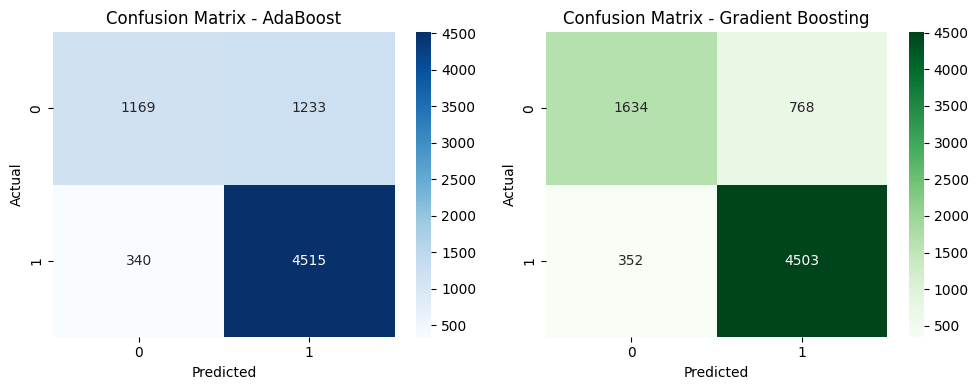

In [101]:
# Step 7: Confusion Matrices
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

cm_ada = confusion_matrix(y_test, y_pred_ada)
sns.heatmap(cm_ada, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title("Confusion Matrix - AdaBoost")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")

cm_gb = confusion_matrix(y_test, y_pred_gb)
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title("Confusion Matrix - Gradient Boosting")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [102]:
# Step 8: Comparison Table
results = pd.DataFrame({
    "Model": ["AdaBoost", "Gradient Boosting"],
    "Accuracy": [
        round(accuracy_score(y_test, y_pred_ada), 3),
        round(accuracy_score(y_test, y_pred_gb), 3)
    ]
})

print("\n📊 Model Comparison Table:")
print(results)


📊 Model Comparison Table:
               Model  Accuracy
0           AdaBoost     0.783
1  Gradient Boosting     0.846


**📌Bagging and Stacking :**                                             Bagging and Stacking are used to improve model performance, reduce errors, and build more robust predictions using ensemble learning techniques.

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Base models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC

In [104]:
# Step 2: Load and preprocess dataset
df = pd.read_csv("/content/booking.csv")
print("✅ Dataset Loaded Successfully!\n")

# Drop unnecessary columns
df = df.drop(columns=["Booking_ID", "date of reservation"], errors='ignore')

# Encode target
le = LabelEncoder()
df["booking status"] = le.fit_transform(df["booking status"])

# One-hot encode categorical columns
df = pd.get_dummies(df, drop_first=True)

# Handle missing values
df = df.fillna(df.mean())

✅ Dataset Loaded Successfully!



In [105]:
# Step 3: Define features (X) and target (y)
X = df.drop("booking status", axis=1)
y = df["booking status"]

In [106]:
# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [107]:
# Step 5: Standardize numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [108]:
# Step 6: Define base models (Level-0)
base_models = [
    ('lr', LogisticRegression(max_iter=1000)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('gb', GradientBoostingClassifier(random_state=42))
]

In [109]:
# Step 7: Define meta-model (Level-1)
meta_model = LogisticRegression(max_iter=1000)

In [110]:
# Step 8: Build Stacking Classifier
stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1
)

In [111]:
# Step 9: Train and Evaluate Models
# Train base models individually for comparison
model_results = []

for name, model in base_models:
    if name in ['lr', 'knn']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    model_results.append([name, acc])

# Train and evaluate Stacking Classifier
stack_model.fit(X_train_scaled, y_train)
y_pred_stack = stack_model.predict(X_test_scaled)
stack_acc = accuracy_score(y_test, y_pred_stack)
model_results.append(['stacking', stack_acc])

In [112]:
# Step 10: Observation Table
results_df = pd.DataFrame(model_results, columns=["Model", "Accuracy"])
results_df = results_df.sort_values(by="Accuracy", ascending=False)
print("\n📊 Model Comparison Table:\n")
print(results_df)


📊 Model Comparison Table:

      Model  Accuracy
5  stacking  0.891415
3        rf  0.888246
1       knn  0.852143
4        gb  0.845666
2        dt  0.832024
0        lr  0.801433


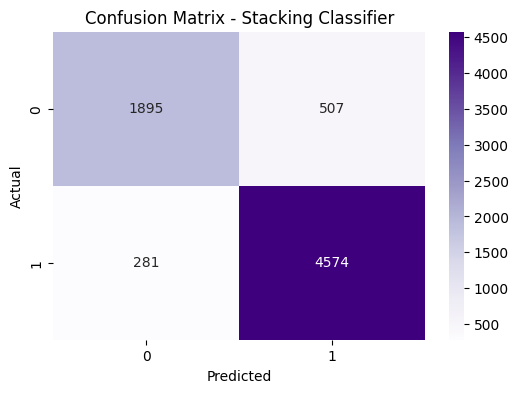

In [113]:
# Step 11: Confusion Matrix for Stacking Model
cm = confusion_matrix(y_test, y_pred_stack)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix - Stacking Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [114]:
# Step 12: Classification Report
print("\n📋 Classification Report - Stacking Model:\n")
print(classification_report(y_test, y_pred_stack))


📋 Classification Report - Stacking Model:

              precision    recall  f1-score   support

           0       0.87      0.79      0.83      2402
           1       0.90      0.94      0.92      4855

    accuracy                           0.89      7257
   macro avg       0.89      0.87      0.87      7257
weighted avg       0.89      0.89      0.89      7257



**Final Model Selection :** Random Forest

In [115]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Ignore warnings for clean output
import warnings
warnings.filterwarnings('ignore')

In [116]:
# Step 2: Load Dataset
df = pd.read_csv("/content/booking.csv")
print("✅ Dataset loaded successfully.")
print(df.head())

✅ Dataset loaded successfully.
  Booking_ID  number of adults  number of children  number of weekend nights  \
0   INN00001                 1                   1                         2   
1   INN00002                 1                   0                         1   
2   INN00003                 2                   1                         1   
3   INN00004                 1                   0                         0   
4   INN00005                 1                   0                         1   

   number of week nights  type of meal  car parking space    room type  \
0                      5   Meal Plan 1                  0  Room_Type 1   
1                      3  Not Selected                  0  Room_Type 1   
2                      3   Meal Plan 1                  0  Room_Type 1   
3                      2   Meal Plan 1                  0  Room_Type 1   
4                      2  Not Selected                  0  Room_Type 1   

   lead time market segment type  repeated 

In [117]:
# Step 3: Basic Preprocessing
# Drop unnecessary columns (if any)
df = df.drop(columns=["Booking_ID", "date of reservation"], errors='ignore')

# Handle missing values
df = df.fillna(df.mean(numeric_only=True))

# Encode target variable
le = LabelEncoder()
df["booking status"] = le.fit_transform(df["booking status"])

# Identify features and target
X = df.drop("booking status", axis=1)
y = df["booking status"]

# Detect categorical columns
cat_cols = X.select_dtypes(include=["object"]).columns
num_cols = X.select_dtypes(exclude=["object"]).columns

print("\nCategorical columns:", list(cat_cols))
print("Numerical columns:", list(num_cols))


Categorical columns: ['type of meal', 'room type', 'market segment type']
Numerical columns: ['number of adults', 'number of children', 'number of weekend nights', 'number of week nights', 'car parking space', 'lead time', 'repeated', 'P-C', 'P-not-C', 'average price', 'special requests']


In [118]:
# Step 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("\n✅ Data split into training and test sets.")


✅ Data split into training and test sets.


In [119]:
# Step 5: Build Preprocessing Pipeline
from sklearn.preprocessing import OneHotEncoder

# Transform categorical columns (OneHotEncoder) and scale numeric columns
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

In [120]:
# Step 6: Define Candidate Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel="rbf", probability=True),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

In [122]:
# Step 7: Train and Evaluate Models (Pipeline Integration)
results = []

for name, model in models.items():
    # Create pipeline for each model
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    # Cross-validation for stable performance estimate
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="accuracy")

    # Train and predict
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results.append([name, acc, cv_scores.mean()])

    print(f"\n📊 {name} Results:")
    print("Test Accuracy:", round(acc, 3))
    print("Cross-Val Mean Accuracy:", round(cv_scores.mean(), 3))
    print(classification_report(y_test, y_pred))


📊 Logistic Regression Results:
Test Accuracy: 0.806
Cross-Val Mean Accuracy: 0.798
              precision    recall  f1-score   support

           0       0.75      0.62      0.68      2378
           1       0.83      0.90      0.86      4879

    accuracy                           0.81      7257
   macro avg       0.79      0.76      0.77      7257
weighted avg       0.80      0.81      0.80      7257


📊 KNN Results:
Test Accuracy: 0.858
Cross-Val Mean Accuracy: 0.844
              precision    recall  f1-score   support

           0       0.80      0.76      0.78      2378
           1       0.88      0.91      0.90      4879

    accuracy                           0.86      7257
   macro avg       0.84      0.83      0.84      7257
weighted avg       0.86      0.86      0.86      7257


📊 Decision Tree Results:
Test Accuracy: 0.832
Cross-Val Mean Accuracy: 0.831
              precision    recall  f1-score   support

           0       0.76      0.71      0.73      2378
       

In [123]:
# Step 8: Observation Table
results_df = pd.DataFrame(results, columns=["Model", "Test Accuracy", "CV Accuracy"])
results_df = results_df.sort_values(by="Test Accuracy", ascending=False)
print("\n✅ Final Model Comparison Table:\n")
print(results_df)


✅ Final Model Comparison Table:

                 Model  Test Accuracy  CV Accuracy
3        Random Forest       0.891002     0.881563
1                  KNN       0.857792     0.843703
5    Gradient Boosting       0.853245     0.846218
4                  SVM       0.836434     0.827684
2        Decision Tree       0.831749     0.831439
0  Logistic Regression       0.805843     0.797919


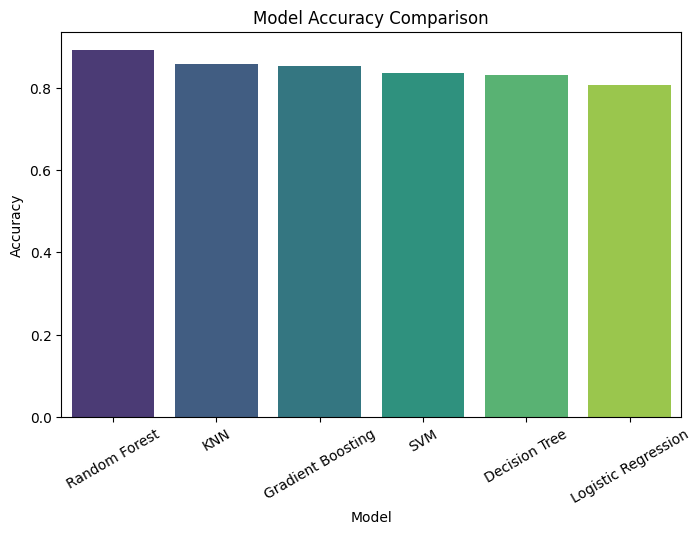

In [124]:
# Step 9: Visualization
plt.figure(figsize=(8,5))
sns.barplot(data=results_df, x="Model", y="Test Accuracy", palette="viridis")
plt.xticks(rotation=30)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [125]:
# Step 10: Final Model Selection
best_model_name = results_df.iloc[0, 0]
best_model_acc = results_df.iloc[0, 1]
print(f"\n🏆 Final Selected Model: {best_model_name} (Accuracy = {best_model_acc:.3f})")


🏆 Final Selected Model: Random Forest (Accuracy = 0.891)


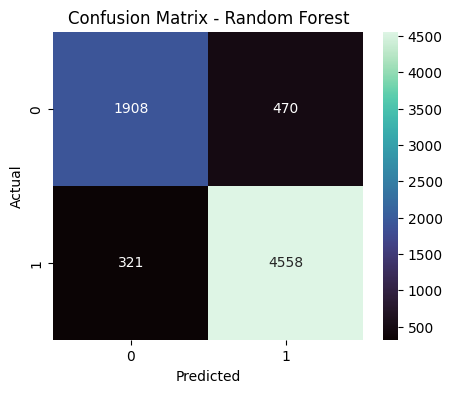

In [126]:
# Step 11: Confusion Matrix of Final Model
final_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", models[best_model_name])
])
final_pipe.fit(X_train, y_train)
y_pred_final = final_pipe.predict(X_test)

cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="mako")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [127]:
# Step 12: Conclusion
print(f"""
✅ CONCLUSION:
The end-to-end ML pipeline successfully automated data preprocessing, model training,
cross-validation, and evaluation for the booking dataset.

The best-performing model was **{best_model_name}** with a test accuracy of **{round(best_model_acc, 3)}**.

This pipeline approach ensures modular, reusable, and scalable ML workflow —
ready for deployment in real-world scenarios.
""")


✅ CONCLUSION:
The end-to-end ML pipeline successfully automated data preprocessing, model training,
cross-validation, and evaluation for the booking dataset.

The best-performing model was **Random Forest** with a test accuracy of **0.891**.

This pipeline approach ensures modular, reusable, and scalable ML workflow —
ready for deployment in real-world scenarios.



**End-to-End Data Pipeline**

In [128]:
# 1. Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier

# -------------------------------------------------------
# 2. Load Dataset
df = pd.read_csv("booking.csv")

# -------------------------------------------------------
# 3. Cleanup

# Drop Booking_ID (irrelevant)
df = df.drop(columns=["Booking_ID"])

# Convert target to numeric
df["booking status"] = df["booking status"].map({
    "Canceled": 1,
    "Not_Canceled": 0
})

# -------------------------------------------------------
# 4. Convert date column safely (mixed formats)
# -------------------------------------------------------
df["date of reservation"] = pd.to_datetime(
    df["date of reservation"],
    format="mixed",
    dayfirst=False,
    errors="coerce"       # invalid dates → NaT
)

# Extract date features
df["res_year"] = df["date of reservation"].dt.year
df["res_month"] = df["date of reservation"].dt.month
df["res_day"] = df["date of reservation"].dt.day

# Handle missing dates (NaT)
df["res_year"].fillna(df["res_year"].mode()[0], inplace=True)
df["res_month"].fillna(df["res_month"].mode()[0], inplace=True)
df["res_day"].fillna(df["res_day"].mode()[0], inplace=True)

# Drop original date column
df = df.drop(columns=["date of reservation"])

# -------------------------------------------------------
# 5. Define Features & Target
# -------------------------------------------------------
X = df.drop(columns=["booking status"])
y = df["booking status"]

# Identify categorical & numeric features
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

# -------------------------------------------------------
# 6. Preprocessing using ColumnTransformer
# -------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

# -------------------------------------------------------
# 7. Build ML Pipeline (Random Forest)
# -------------------------------------------------------
model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        max_depth=14,
        random_state=42
    ))
])

# -------------------------------------------------------
# 8. Train-Test Split
# -------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# -------------------------------------------------------
# 9. Train Model
# -------------------------------------------------------
model.fit(X_train, y_train)

# -------------------------------------------------------
# 10. Evaluate Model
# -------------------------------------------------------
preds = model.predict(X_test)

print("ACCURACY:", accuracy_score(y_test, preds))
print("\nCLASSIFICATION REPORT:\n")
print(classification_report(y_test, preds))

# -------------------------------------------------------
# 11. Prediction Function (for single booking)
# -------------------------------------------------------
def predict_booking(sample_dict):
    sample = pd.DataFrame([sample_dict])

    # Convert date
    if "date of reservation" in sample:
        sample["date of reservation"] = pd.to_datetime(
            sample["date of reservation"],
            format="mixed",
            errors="coerce"
        )
        sample["res_year"] = sample["date of reservation"].dt.year.fillna(df["res_year"].mode()[0])
        sample["res_month"] = sample["date of reservation"].dt.month.fillna(df["res_month"].mode()[0])
        sample["res_day"] = sample["date of reservation"].dt.day.fillna(df["res_day"].mode()[0])
        sample = sample.drop(columns=["date of reservation"])

    pred = model.predict(sample)[0]
    return "Canceled" if pred == 1 else "Not_Canceled"



ACCURACY: 0.8889991181657848

CLASSIFICATION REPORT:

              precision    recall  f1-score   support

           0       0.90      0.94      0.92      6100
           1       0.87      0.78      0.82      2972

    accuracy                           0.89      9072
   macro avg       0.88      0.86      0.87      9072
weighted avg       0.89      0.89      0.89      9072



In [129]:
predict_booking({
    "number of adults": 2,
    "number of children": 1,
    "number of weekend nights": 1,
    "number of week nights": 3,
    "type of meal": "Meal Plan 1",
    "car parking space": 0,
    "room type": "Room_Type 1",
    "lead time": 15,
    "market segment type": "Online",
    "repeated": 0,
    "P-C": 0,
    "P-not-C": 0,
    "average price": 95,
    "special requests": 1,
    "date of reservation": "6/12/2018"
})


'Not_Canceled'

In [130]:
print(predict_booking({
    "number of adults": 1,
    "number of children": 0,
    "number of weekend nights": 0,
    "number of week nights": 1,
    "type of meal": "Not Selected",
    "car parking space": 0,
    "room type": "Room_Type 3",
    "lead time": 280,
    "market segment type": "Online",
    "repeated": 0,
    "P-C": 0,
    "P-not-C": 1,
    "average price": 170,
    "special requests": 0,
    "date of reservation": "1/5/2017"
}))



Canceled


In [131]:
# Function to take user input and predict booking cancellation
def user_input_predict():
    print("Enter Booking Details:\n")

    data = {
        "number of adults": int(input("Number of adults: ")),
        "number of children": int(input("Number of children: ")),
        "number of weekend nights": int(input("Number of weekend nights: ")),
        "number of week nights": int(input("Number of week nights: ")),
        "type of meal": input("Type of meal (Meal Plan 1 / Meal Plan 2 / Not Selected): "),
        "car parking space": int(input("Car parking space (0/1): ")),
        "room type": input("Room type (Room_Type 1, Room_Type 2, ...): "),
        "lead time": int(input("Lead time: ")),
        "market segment type": input("Market segment type (Online / Offline): "),
        "repeated": int(input("Repeated customer (0/1): ")),
        "P-C": int(input("P-C: ")),
        "P-not-C": int(input("P-not-C: ")),
        "average price": float(input("Average price: ")),
        "special requests": int(input("Special requests: ")),
        "date of reservation": input("Date of reservation (e.g., 6/12/2018 or 2018-06-12): ")
    }

    result = predict_booking(data)
    print("\nPrediction:", result)


In [132]:
user_input_predict()


Enter Booking Details:

Number of adults: 2
Number of children: 1
Number of weekend nights: 2
Number of week nights: 1
Type of meal (Meal Plan 1 / Meal Plan 2 / Not Selected): Meal Plan 1
Car parking space (0/1): 1
Room type (Room_Type 1, Room_Type 2, ...): Room_Type 2
Lead time: 10
Market segment type (Online / Offline): Online
Repeated customer (0/1): 1
P-C: 0
P-not-C: 0
Average price: 120
Special requests: 1
Date of reservation (e.g., 6/12/2018 or 2018-06-12): 6/12/2018 

Prediction: Not_Canceled


## ✅ Results & Conclusion

- The model successfully predicts booking cancellations.
- Important factors influencing cancellations include:
  - Lead time
  - Price
  - Market segment
- The best-performing model is selected based on evaluation metrics.

## 🚀 Future Improvements
- Use advanced models like XGBoost or LightGBM
- Deploy the model as a web application
- Integrate real-time booking prediction system